Amount of features: 5, amount of datapoints: 1503
0
3
378
1125


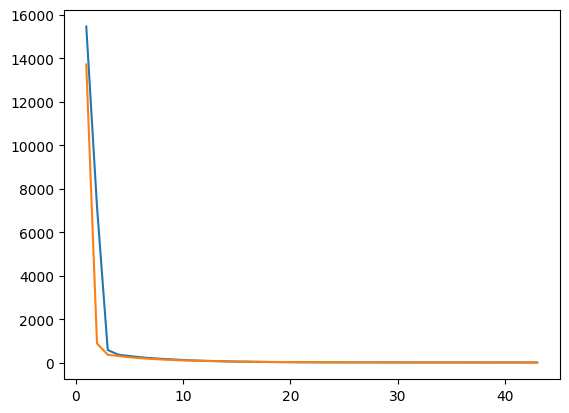

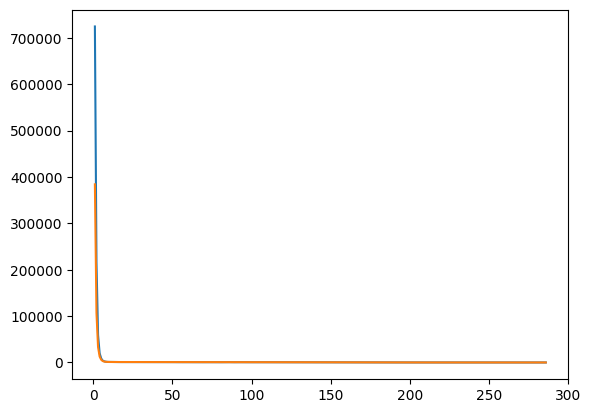

5.504995


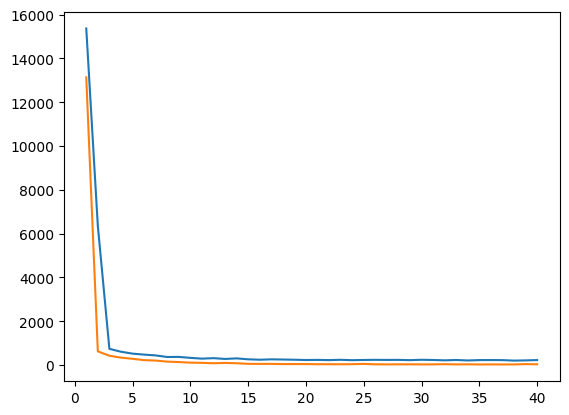

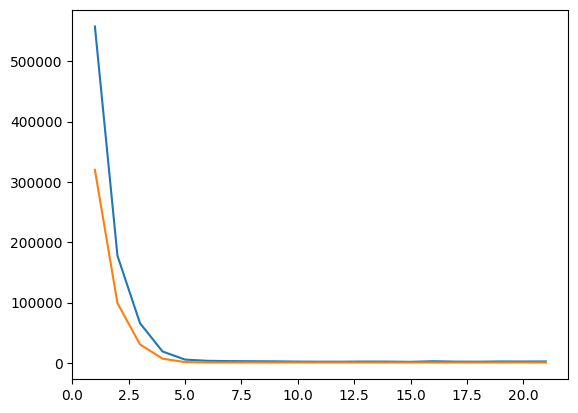

26.455885


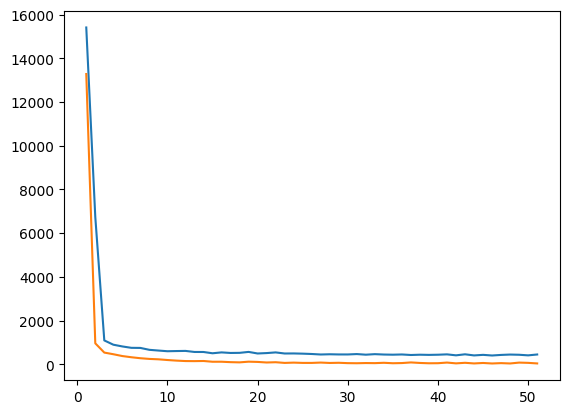

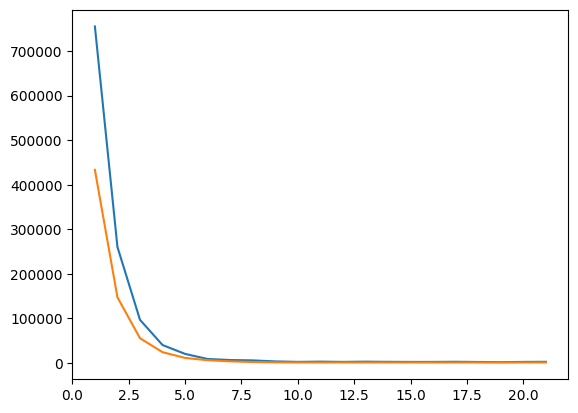

30.891878


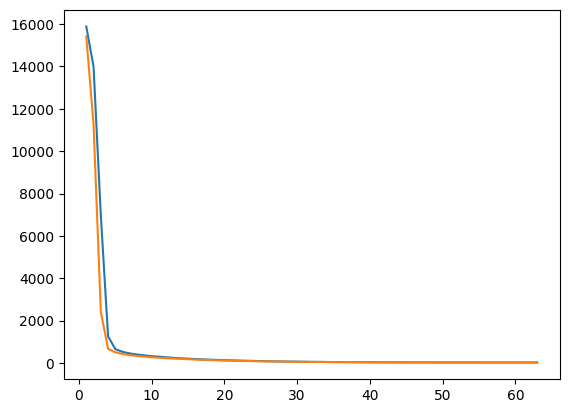

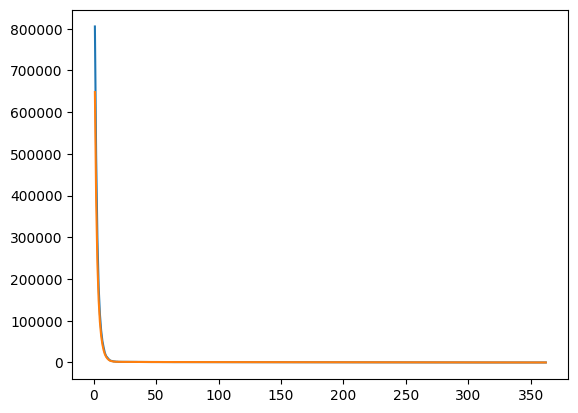

6.394319


KeyboardInterrupt: 

In [2]:
import sys

sys.path.append('../')

from baselines import *
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from utils import *  #only needed for xgboost
import uci_config as c

from ucimlrepo import fetch_ucirepo 

id_list = [291] #InfraRed = 925, concrete = 165, Auto MPG = 9, 
        #Real estate valuation = 477, Air-foil self-noise = 291, forest fires = 162

for id in id_list:

    df_exp = pd.DataFrame(columns = ['seed', 'learning_rate', 'dropout',
                                                          'val_rmse', 'val_mae', 'rmse', 'mae'])

    for seed in c.seed_list:

        ### Read data from uci and process ###
        data = fetch_ucirepo(id=id)  
        
        # data (as pandas dataframes) 
        X = data.data.features 
        y = data.data.targets

        X = data.data.features.reset_index(drop=True)
        y = data.data.targets.reset_index(drop=True)
        
        print(f'Amount of features: {X.shape[1]}, amount of datapoints: {X.shape[0]}')

        y = y[y.columns[0]] #select first response in cases of several alternatives

        data = X.copy()
        data['target'] = y #add this to the entire data, as we will order them
        data = data.dropna() 
        # Convert object columns to category first
        for col in data.select_dtypes(include='object').columns:
            data[col] = data[col].astype('category')

        # Now convert category columns to numeric codes
        for col in data.select_dtypes(include='category').columns:
            data[col] = data[col].cat.codes

        target_column = 'target'
        predictor_columns = list(X.columns)

        ###############################################

        ### Split the data based on a continuous feature correlaing with response (correlation close to +-0.4)
        #Identify each correlation with target variable
        single_features = []
        features = []
        corr_coefs = []
        for feature in X.columns:
            single_feature = X[feature]
            single_features.append(single_feature)
            features.append(feature)
            if np.issubdtype(single_feature.dtype, np.number):
                corr_coef = single_feature.corr(y)
            else:
                corr_coef = 0
            corr_coefs.append(corr_coef)

        # Select the variable that has correlation closest to 0.4
        threshold = 0.4
        idx = min(range(len(corr_coefs)), key=lambda i: abs(abs(corr_coefs[i]) - threshold)) 
        print(idx)
        closest_value = corr_coefs[idx]
        selected_variable = X.columns[idx]

        #sort by this value, and remove the column!
        data = data.sort_values(by = selected_variable)
        data = data.drop(columns = selected_variable)
        predictor_columns.remove(selected_variable)

        # Split data into four equally sized components
        n = len(data)
        t = n // 4  # size of each part

        df1 = data.iloc[:t]
        df2 = data.iloc[t:2*t]
        df3 = data.iloc[2*t:3*t]
        df4 = data.iloc[3*t:]

        #randomly select the target set
        df = [df1, df2, df3, df4]
        np.random.seed(id)
        random_index =  np.random.choice([0,3])
        print(random_index)
        data_target = df[random_index]
        data_source = pd.concat([df[i] for i in range(4) if i != random_index], ignore_index=True)
        print(len(data_target))
        print(len(data_source))

        ###########################################################

        ### Split data into train/validation/test
        data_temp, data_test = train_test_split(data_target, test_size=0.2, random_state=seed)
        data_train, data_val = train_test_split(data_temp, test_size=0.25, random_state = 3)

        X_source_train = np.array(data_source[predictor_columns])
        y_source_train = np.array(data_source[target_column]) 


        #Specific train and test set
        X_target_train = np.array(data_train[predictor_columns])
        y_target_train = np.array(data_train[target_column])

        X_target_val = np.array(data_val[predictor_columns])
        y_target_val = np.array(data_val[target_column])

        X_target_test = np.array(data_test[predictor_columns])
        y_target_test = np.array(data_test[target_column])

        ############################################################

        ### Loop over possible hyperparameter settings

        for config in c.param_grid_MLP:
            learning_rate, dropout = config

            mlp = MLP(input_size = np.shape(X_target_test)[1], hidden_size_1=64, hidden_size_2=64, 
                    hidden_size_3=32, output_size=1, dropout_rate=dropout, include_batch_norm=False)
            
            dataloader_train = process_dataset_for_base_network(X_source_train, y_source_train, batch_size = 16)
            
            mlp, train_loss, val_loss = train_mlp_on_source(dataloader_train, mlp, learning_rate = learning_rate, epochs=1000)
            x = np.linspace(1,len(train_loss), len(train_loss))
            plt.plot(x, train_loss)
            plt.plot(x, val_loss)
            #plt.ylim([0,50])
            plt.show()
        
            train_dataloader, val_dataloader, test_dataloader = process_datasets_for_finetuning(X_target_train, y_target_train,
                                        X_target_val, y_target_val, X_target_test, y_target_test, batch_size=16)
            
            mlp, train_loss, val_loss = finetune_mlp_on_target(train_dataloader, val_dataloader, mlp, epochs=1000, learning_rate = learning_rate, freeze_layers=None)
            rmse, mae = test_final_mlp(dataloader_test=test_dataloader, mlp=mlp)
            val_rmse, val_mae = test_final_mlp(dataloader_test=val_dataloader, mlp=mlp)
            df_exp.loc[len(df_exp)] = [seed, learning_rate, dropout, val_rmse, val_mae, rmse, mae]
            #df_exp.to_csv(f'results/MLP_target_only_{id}.csv')
            x = np.linspace(1,len(train_loss), len(train_loss))
            plt.plot(x, train_loss)
            plt.plot(x, val_loss)
            #plt.ylim([0,50])
            plt.show()
            print(rmse)

In [ ]:
mlp = MLP(input_size = np.shape(X_target_test)[1], hidden_size_1=64, hidden_size_2=64, 
                    hidden_size_3=32, output_size=1, dropout_rate=0.0, include_batch_norm=False)

pytorch_total_params = sum(p.numel() for p in mlp.parameters())
pytorch_total_params

8385